# Exercise 4.A Introduction to Linear Regression

In [1]:
# Import numpy for numerical calculations
import numpy as np

# Import pandas for working with tables and datasets
import pandas as pd

# Import matplotlib for charts and graphs
import matplotlib.pyplot as plt

# Import train_test_split to divide data into training and testing sets
from sklearn.model_selection import train_test_split

# Import the Linear Regression model
from sklearn.linear_model import LinearRegression

## Lab 1
### Running a sample script

In [2]:
# Sample dataset: hours studied vs. exam score
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)

# Step 1: Define features (X) and target (y)
X = df[['hours_studied']]   # 2D: double brackets give a DataFrame, not a Series
y = df['exam_score']        # 1D: single brackets give a Series

# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Create the model and fit it to training data
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


### Working through the sample script

In [3]:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')


Slope (coefficient): 4.10
Intercept: 47.68


In [5]:
y_pred = model.predict(X_test)
print('Actual scores: ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))

Actual scores:  [85, 55]
Predicted scores: [np.float64(84.6), np.float64(55.9)]


In [6]:
r_squared = model.score(X_test, y_test)
print(f'R² score: {r_squared:.3f}')

R² score: 0.998


What does the R² score mean?

The R² score shows how well the linear regression model explains the relationship between hours studied and exam scores. A score closer to 1 means the model fits the data very well. In this model, the R² score shows that studying hours strongly affects exam scores, so the model is a good fit for the data.

C:\Users\caleb\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


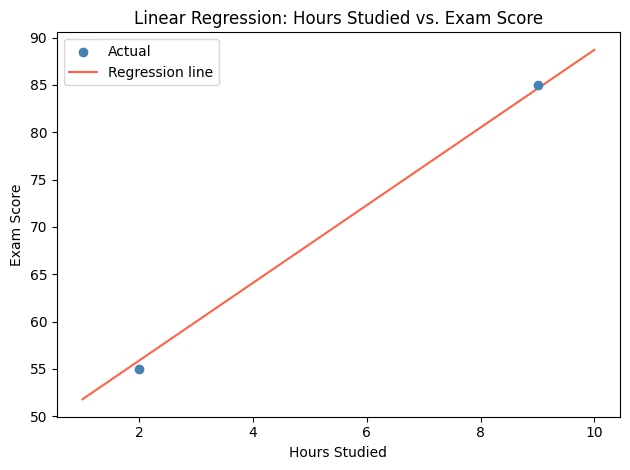

In [7]:
# Scatter plot: actual test data points
plt.scatter(X_test, y_test, color='steelblue', label='Actual',
zorder=3)
# Line: model predictions across the full range of X
x_range = np.linspace(
X['hours_studied'].min(),
X['hours_studied'].max(),
100).reshape(-1, 1)
y_line = model.predict(x_range)
plt.plot(x_range, y_line, color='tomato', label='Regression line')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

Reflection

The actual data points follow the regression line closely. This means there is a strong positive relationship between hours studied and exam scores. As study hours increase, exam scores also increase. The model appears to fit the data well visually.


## Lab 2
### Building your own model

In [11]:

# Create dictionary with ad spend and revenue data
ad_data = {
'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500,
5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000],
'monthly_revenue': [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800,
12400, 13100, 14200, 15600, 15900, 17200, 18100, 19400, 20200, 21500, 22100,
23800]
}

# Create DataFrame
df_ads = pd.DataFrame(ad_data)
print(df_ads)

    monthly_ad_spend  monthly_revenue
0                500             4200
1               1000             5100
2               1500             6800
3               2000             7400
4               2500             8900
5               3000             9200
6               3500            10500
7               4000            11800
8               4500            12400
9               5000            13100
10              5500            14200
11              6000            15600
12              6500            15900
13              7000            17200
14              7500            18100
15              8000            19400
16              8500            20200
17              9000            21500
18              9500            22100
19             10000            23800


In [22]:

# Define feature matrix
X2 = df_ads[['monthly_ad_spend']]

# Define target vector
y2 = df_ads['monthly_revenue']
print('shape of X2:', X2.shape)
print('shape of y2:', y2.shape)

shape of X2: (20, 1)
shape of y2: (20,)


In [33]:
# Split data into training and testing sets
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.3,
    random_state=10
)

In [34]:
# Create Linear Regression model
model2 = LinearRegression()

# Train the model
model2.fit(X2_train, y2_train)

# Print confirmation message
print("Model trained successfully.")

Model trained successfully.


In [35]:
# Print slope and intercept
print(f"Slope: {model2.coef_[0]:.2f}")
print(f"Intercept: {model2.intercept_:.2f}")
# Interpretation:
# For every additional 1 spent on advertising,
# the predicted monthly revenue increases by the slope amount.

Slope: 2.00
Intercept: 3386.09


### Making predictions and evaluating the model

In [27]:
# Predict revenue using test data
y2_pred = model2.predict(X2_test)

# Print actual and predicted values
print("Actual Revenue:")
print(list(y2_test))

print("\nPredicted Revenue:")
print(list(y2_pred.round(2)))

Actual Revenue:
[4200, 21500, 19400, 5100]

Predicted Revenue:
[np.float64(4603.85), np.float64(21229.03), np.float64(19273.13), np.float64(5581.8)]


In [28]:
# Calculate R² score
r2_score = model2.score(X2_test, y2_test)

# Print R² score
print(f"R² score: {r2_score:.3f}")

R² score: 0.998


R² Interpretation

The R² score shows that the model explains most of the variation in monthly revenue using monthly ad spend. The score is close to 1, which means the model is a very good fit. This suggests that advertising spend has a strong effect on revenue.

### Visualizing the results

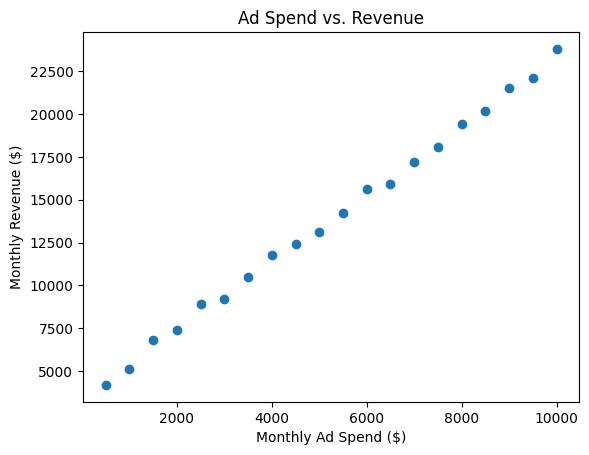

In [31]:
# Create scatter plot
plt.scatter(X2,y2)

# Label x-axis
plt.xlabel('Monthly Ad Spend ($)')

# Label y-axis
plt.ylabel('Monthly Revenue ($)')

# Add title
plt.title('Ad Spend vs. Revenue')

# Display chart
plt.show()

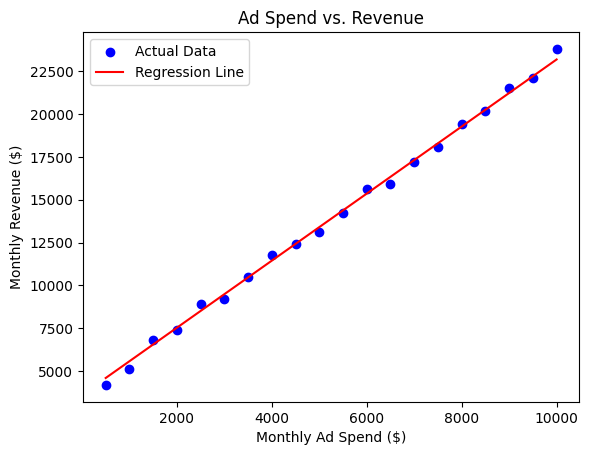

In [32]:
# Scatter plot of actual data
plt.scatter(X2,y2,
    color='blue',
    label='Actual Data'
)

# Predict values for regression line
y2_line = model2.predict(X2)

# Plot regression line
plt.plot(
    X2,
    y2_line,
    color='red',
    label='Regression Line'
)

# Label axes
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')

# Add chart title
plt.title('Ad Spend vs. Revenue')

# Show legend
plt.legend()

# Display chart
plt.show()

Reflection

The regression line fits the data very well visually because most of the data points are close to the line. This matches the R² score, which showed that the model explains a high percentage of the variation in revenue. The model appears to make accurate predictions based on advertising spend.

When I used test_size=0.3 instead of 0.2 and random_state=10, instead of 40, the model still performed well and the regression line continued to fit the data closely. The R² score remained high, which means the relationship between monthly ad spend and monthly revenue is still strong even when the data is split differently.

This experiment showed that different train-test splits can slightly affect the model results, but the overall trend and prediction accuracy stayed consistent because the dataset has a strong linear relationship between advertising spend and revenue.